In [1]:
# Task 5 – Machine Learning Classification Model

# Import required libraries
import pandas as pd
import numpy as np

# Load the cleaned Netflix dataset
netflix_dataset = pd.read_csv(
    r"C:\Users\user\Desktop\internship work\TASK 1\netflix_dataset.csv"
)

# Display first 5 rows
netflix_dataset.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min,2021,9
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Season,2021,9
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,Season,2021,9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min,2021,9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min,2021,9


In [2]:
# Step 1: Select and prepare features

# Select input features
features = ["release_year", "duration_value", "year_added", "month_added", "rating"]

X = netflix_dataset[features]
y = netflix_dataset["type"]

# Convert rating into numerical dummy variables
X = pd.get_dummies(X, columns=["rating"], drop_first=True)

# Display the prepared features
X.head()


,release_year,duration_value,year_added,month_added,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,2020,90,2021,9,False,False,False,True,False,False,False,False,False,False,False,False,False
1,2021,1,2021,9,False,False,False,False,False,False,False,True,False,False,False,False,False
2,2021,1,2021,9,False,False,False,False,False,False,False,True,False,False,False,False,False
3,2021,91,2021,9,False,False,False,False,False,False,False,False,True,False,False,False,False
4,1993,125,2021,9,False,False,False,False,False,False,False,True,False,False,False,False,False


In [3]:
# Prepare the target variable

# Convert type into numerical classes
y = y.map({
    "Movie": 0,
    "TV Show": 1
})

# Check the target values
print("Target classes:")
print(y.value_counts())

print("\nFirst 5 target values:")
print(y.head())

Target classes:
type
0    6126
1    2664
Name: count, dtype: int64

First 5 target values:
0    0
1    1
2    1
3    0
4    0
Name: type, dtype: int64


In [4]:
# Step 2: Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the size of the datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (7032, 17)
Testing features: (1758, 17)
Training target: (7032,)
Testing target: (1758,)


In [5]:
# Step 3: Train classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Create the models
logistic_model = LogisticRegression(max_iter=1000)
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train Logistic Regression
logistic_model.fit(X_train, y_train)

# Train Decision Tree
decision_tree_model.fit(X_train, y_train)

print("Both models have been trained successfully.")

Both models have been trained successfully.


In [6]:
# Step 4: Evaluate model performance

from sklearn.metrics import accuracy_score

# Make predictions
logistic_predictions = logistic_model.predict(X_test)
decision_tree_predictions = decision_tree_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)

# Display accuracy
print("Logistic Regression Accuracy:", logistic_accuracy)
print("Decision Tree Accuracy:", decision_tree_accuracy)

Logistic Regression Accuracy: 0.9982935153583617
Decision Tree Accuracy: 0.9960182025028441


In [7]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    logistic_predictions,
    target_names=["Movie", "TV Show"]
))

print("\nDecision Tree Classification Report")
print(classification_report(
    y_test,
    decision_tree_predictions,
    target_names=["Movie", "TV Show"]
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758


Decision Tree Classification Report
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       0.99      0.99      0.99       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



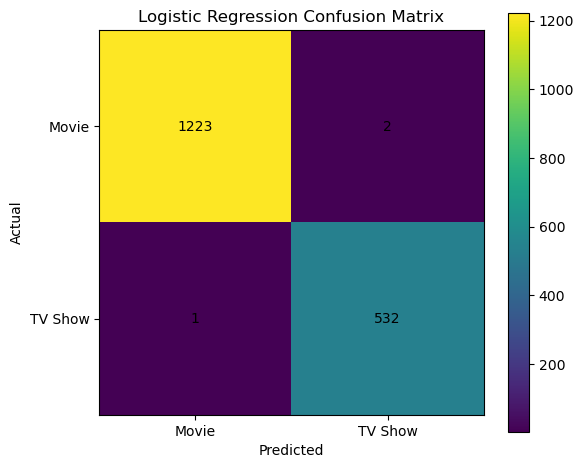

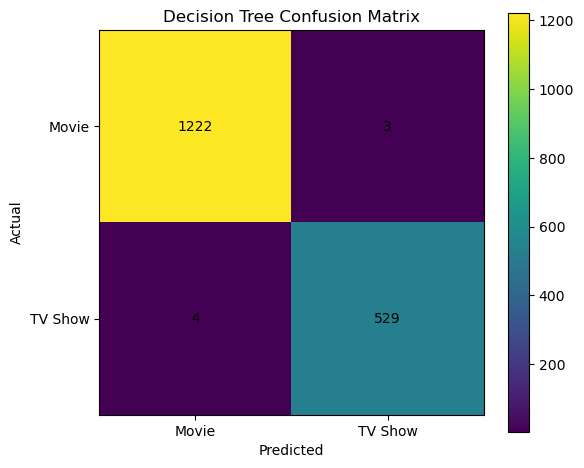

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrices
logistic_cm = confusion_matrix(y_test, logistic_predictions)
decision_tree_cm = confusion_matrix(y_test, decision_tree_predictions)

# Display Logistic Regression confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(logistic_cm)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Movie", "TV Show"])
plt.yticks([0, 1], ["Movie", "TV Show"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, logistic_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# Display Decision Tree confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(decision_tree_cm)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Movie", "TV Show"])
plt.yticks([0, 1], ["Movie", "TV Show"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, decision_tree_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [9]:
# Step 5: Compare model accuracy

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, decision_tree_accuracy]
})

# Convert accuracy to percentage
comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

# Display comparison
comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.998294,99.829352
1,Decision Tree,0.996018,99.601820


Final conclusion for Task 5

The results show that both models performed very well in classifying Netflix content into Movies and TV Shows. Logistic Regression achieved the highest accuracy of 99.83%, while Decision Tree achieved 99.60%. Therefore, Logistic Regression was selected as the best-performing model for this classification task.